# DFT Ground-State Energy of the Helium Atom

We compute the ground-state energy of helium from scratch, in **atomic units**
($\hbar = m_e = e = 4\pi\varepsilon_0 = 1$; length in Bohr, energy in Hartree).

The plan, built one milestone at a time (see `pdocs/project_spec.md`):

- **M0** — Scaffolding: radial grid, parameters, one reusable integrator.
- **M1** — Hydrogen radial solver: one electron in a bare nucleus $-Z/r$.
- **M2** — Hartree potential: the repulsion the electron cloud creates.
- **M3** — Self-consistent helium, Hartree only (no XC) → $-2.86$ (= RHF).
- **M4** — Add LDA (Slater) exchange → $-2.72$.
- **M5** — Add LDA (Perdew-Zunger) correlation → $-2.83$. The full LDA result.
- M6 — Report figures (not yet done).

**This notebook currently covers M0 through M5 — all the physics milestones.**

**Code layout.** The validated physics lives in the module **`dft.py`** (grid,
integrator, Numerov solver, root finder, Poisson solver, SCF loops). This notebook
imports from it and keeps only the narrative, the demo calls, and the plots — so
the notebook and the test suite (`tests/test_dft.py`) exercise *exactly the same*
code. Run `pytest -v` to check every milestone's validation gate at once.

The headline idea: with two electrons the problem is not analytically solvable
because each electron feels the other. DFT sidesteps this by tracking the
**electron cloud** (the density) instead of the individual electrons, and
solving a self-consistent loop. But first we must be able to solve the simplest
case exactly — a single electron near a nucleus — which is M1.

**The story in one line:** as we add each piece of physics the energy marches
toward the truth — $-2.86$ (Hartree/HF) → $-2.72$ (+ LDA exchange) → $-2.83$
(+ LDA correlation), versus the exact $-2.90$.

---
## Milestone 0 — Scaffolding

**Goal:** a notebook that runs top to bottom, with the pieces every later
milestone reuses:

1. A **radial grid**. Because the 1s orbital is spherically symmetric, every
   quantity depends only on the radius $r$. We discretise $r$ on a uniform grid.
2. A **parameters block** (nuclear charge $Z$, step $h$, outer radius $r_{max}$,
   trial energy) so the physics inputs live in one place.
3. One **reusable 1-D integrator**. We need $\int f(r)\,dr$ repeatedly (to
   normalise the wavefunction, to build the Hartree energy, etc.), so we write
   it once.

**Key pitfall (from the spec):** potentials go as $1/r$, which blows up at
$r=0$. So the grid **starts at $r = h$, not $r = 0$**. We never evaluate
anything at the origin.

**Validation gate:** the notebook executes with no error and prints a smoke test.

In [1]:
# Only numpy and matplotlib are allowed (spec section 3). The numerics
# (integration, root finding, Poisson) are all hand-written in dft.py on
# purpose, so that every line is explainable to an examiner.
import numpy as np
import matplotlib.pyplot as plt

# The physics engine. We import the functions by name so the demo cells below
# read naturally (find_eigenvalue(...), hartree_potential(...), etc.).
import dft
from dft import (make_grid, integrate, solve_radial, shoot, normalise,
                 eigenstate, find_eigenvalue, hartree_potential,
                 scf_no_xc, exchange_potential, scf_lda_x,
                 correlation_pz, scf_lda_xc, H_STEP, R_MAX)

In [2]:
# ----------------------------------------------------------------------------
# Parameters block: the physical / numerical inputs.
# ----------------------------------------------------------------------------
# Z      : nuclear charge. Z = 1 is hydrogen (our M1 warm-up), Z = 2 is helium.
# H_STEP : grid spacing in Bohr (defined in dft.py). We use 0.001: the steep
#          e^{-Zr} cusp of the Z=2 orbital needs fine resolution near the nucleus
#          to hit E=-2.0 (at h=0.005 the Z=2 eigenvalue is off by ~1.5e-3; at
#          0.001, ~6e-5). The spec recommends the 0.001-0.01 range.
# R_MAX  : outer edge of the grid in Bohr (defined in dft.py). The 1s orbital
#          decays like e^{-Zr}, so by ~25 Bohr it is negligible -- effectively
#          "infinity", far enough that the boundary does not distort the answer.
# The grid starts at r = h (NOT 0): the potentials go as 1/r and would blow up
# at the origin, so we step one point out and never evaluate anything at r = 0.
Z = 2.0          # default to helium's nucleus; the demos below override per test

r = make_grid()  # uniform grid r = h, 2h, ..., r_max (uses dft.H_STEP, dft.R_MAX)
print(f"Grid: N = {len(r)} points, r[0] = {r[0]:.4f} Bohr, "
      f"r[-1] = {r[-1]:.4f} Bohr, h = {H_STEP} Bohr")

Grid: N = 25000 points, r[0] = 0.0010 Bohr, r[-1] = 25.0000 Bohr, h = 0.001 Bohr


In [3]:
# M0 smoke test. `integrate` (composite Simpson's rule, defined in dft.py) is the
# one reusable integrator reused everywhere downstream: normalising u (M1), the
# enclosed charge q_max (M2), and the energy integrals (M3+). We test it on a
# function with a known answer before trusting it: integral of e^{-r} over
# [0, inf) is 1. (Our grid starts at h and stops at R_MAX, so we expect ~1.)
test_val = integrate(np.exp(-r))
print(f"M0 smoke test: integral of e^(-r) over the grid = {test_val:.6f} "
      f"(analytic value over [0, inf) = 1.0)")
print("M0 OK: notebook runs, grid + parameters + integrator are in place.")

M0 smoke test: integral of e^(-r) over the grid = 0.999000 (analytic value over [0, inf) = 1.0)
M0 OK: notebook runs, grid + parameters + integrator are in place.


---
## Milestone 1 — Hydrogen radial solver (the core engine)

**Goal:** find the bound-state energy $E$ and wavefunction of a single electron
in a bare nuclear potential $V(r) = -Z/r$. This is the engine we reuse, with a
richer $V(r)$, for every later milestone.

**The equation.** For an $l=0$ (s) state, writing $u(r) = r\,R(r)$, the radial
Schrödinger equation collapses to a clean 1-D form (PDF Eq. 1):

$$ u''(r) = 2\,[\,V(r) - E\,]\,u(r), \qquad V(r) = -\frac{Z}{r}. $$

This has the shape $u'' = g(r)\,u$ with $g(r) = 2[V(r)-E]$.

**How we solve it — three ideas:**

1. **Numerov integration.** A finite-difference scheme tailored to $u'' = g\,u$
   that is accurate to $O(h^6)$:
   $$\Big(1 - \tfrac{h^2}{12}g_{n+1}\Big)u_{n+1}
     = 2\Big(1 + \tfrac{5h^2}{12}g_n\Big)u_n
     - \Big(1 - \tfrac{h^2}{12}g_{n-1}\Big)u_{n-1}.$$

2. **Integrate inward** (from $r_{max}$ toward $r=0$), *not* outward. Far away
   the physical bound state decays as $e^{-\kappa r}$ with $\kappa=\sqrt{-2E}$.
   Stepping inward, this decaying solution *grows*, while the unphysical
   $e^{+\kappa r}$ solution *shrinks away* — so inward integration automatically
   stays locked onto the physical solution. We seed it at the outer edge with
   $u(r_{max}) = r_{max}\,e^{-\kappa r_{max}}$ and the same form one step in. The
   overall scale is arbitrary (the equation is linear); we fix it later by
   normalising.

3. **Bisection on $E$.** A bound state must also satisfy $u(0)=0$. For a random
   $E$ the inward solution will *not* vanish at the origin — extrapolated to
   $r=0$ it lands at some nonzero value $u(0;E)$. As $E$ sweeps through a true
   eigenvalue, $u(0;E)$ changes sign. We bracket that sign change and bisect to
   pin down $E$. The **lowest** such $E$ is the ground state (no nodes).

**Validation gate:**
- $Z=1 \Rightarrow E = -0.5$ Ha and $u(r) \approx 2\,r\,e^{-r}$ (hydrogen 1s).
- $Z=2 \Rightarrow E = -2.0$ Ha (bare He$^+$, value $-Z^2/2$).

In [4]:
# ----------------------------------------------------------------------------
# VALIDATION GATE 1a: hydrogen, Z = 1. Expect E = -0.5 Ha, u(r) ~ 2 r e^{-r}.
# ----------------------------------------------------------------------------
E_H, u_H = find_eigenvalue(Z=1.0, r=r)

# Analytic hydrogen 1s, already normalised: integral (2 r e^{-r})^2 dr = 1.
u_H_exact = 2.0 * r * np.exp(-r)
max_wf_err = np.max(np.abs(u_H - u_H_exact))

print("VALIDATION 1a  (hydrogen, Z = 1)")
print(f"  Energy E      = {E_H:.6f} Ha     target = -0.500000 Ha")
print(f"  |E - target|  = {abs(E_H - (-0.5)):.2e} Ha")
print(f"  max|u - 2r e^-r| over grid = {max_wf_err:.2e}  (want ~0)")
print(f"  normalisation: integral u^2 dr = {integrate(u_H * u_H):.6f}  (want 1)")
ok_1a = abs(E_H - (-0.5)) < 1e-3 and max_wf_err < 1e-2
print(f"  --> {'PASS' if ok_1a else 'FAIL'}")

VALIDATION 1a  (hydrogen, Z = 1)
  Energy E      = -0.499996 Ha     target = -0.500000 Ha
  |E - target|  = 3.98e-06 Ha
  max|u - 2r e^-r| over grid = 6.77e-06  (want ~0)
  normalisation: integral u^2 dr = 1.000000  (want 1)
  --> PASS


In [5]:
# ----------------------------------------------------------------------------
# VALIDATION GATE 1b: bare He+ nucleus, Z = 2, no electron-electron repulsion
# yet. The exact one-electron result is E = -Z^2/2 = -2.0 Ha.
# ----------------------------------------------------------------------------
E_He, u_He = find_eigenvalue(Z=2.0, r=r)

# Analytic He+ 1s for reference: u = 2 Z^{3/2} r e^{-Z r}, normalised.
u_He_exact = 2.0 * Z**1.5 * r * np.exp(-2.0 * r)  # Z = 2 here
max_wf_err_He = np.max(np.abs(u_He - u_He_exact))

print("VALIDATION 1b  (bare He+ nucleus, Z = 2, no Hartree)")
print(f"  Energy E      = {E_He:.6f} Ha     target = -2.000000 Ha")
print(f"  |E - target|  = {abs(E_He - (-2.0)):.2e} Ha")
print(f"  max|u - 2 Z^1.5 r e^-Zr| over grid = {max_wf_err_He:.2e}  (want ~0)")
print(f"  normalisation: integral u^2 dr = {integrate(u_He * u_He):.6f}  (want 1)")
ok_1b = abs(E_He - (-2.0)) < 1e-3
print(f"  --> {'PASS' if ok_1b else 'FAIL'}")

print()
print("=" * 60)
print(f"MILESTONE 1 OVERALL: {'PASS' if (ok_1a and ok_1b) else 'FAIL'}")
print("=" * 60)

VALIDATION 1b  (bare He+ nucleus, Z = 2, no Hartree)
  Energy E      = -1.999937 Ha     target = -2.000000 Ha
  |E - target|  = 6.35e-05 Ha
  max|u - 2 Z^1.5 r e^-Zr| over grid = 3.81e-05  (want ~0)
  normalisation: integral u^2 dr = 1.000000  (want 1)
  --> PASS

MILESTONE 1 OVERALL: PASS


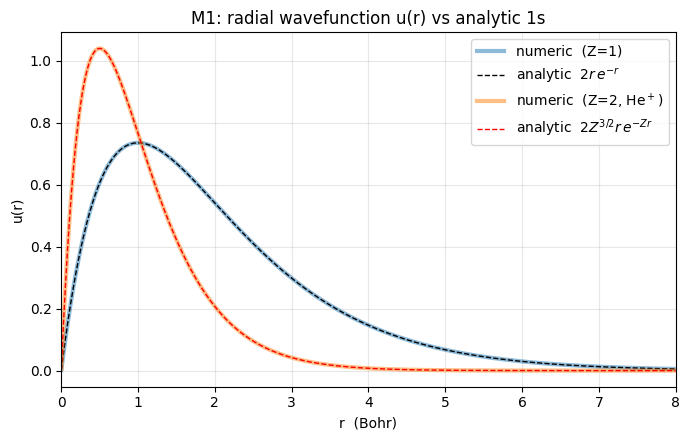

In [6]:
# Visual check: the numeric u(r) should sit right on top of the analytic curve.
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(r, u_H, lw=3, alpha=0.5, label="numeric  (Z=1)")
ax.plot(r, u_H_exact, "k--", lw=1, label=r"analytic  $2r\,e^{-r}$")
ax.plot(r, u_He, lw=3, alpha=0.5, label="numeric  (Z=2, He$^+$)")
ax.plot(r, u_He_exact, "r--", lw=1, label=r"analytic  $2Z^{3/2}r\,e^{-Zr}$")
ax.set_xlim(0, 8)
ax.set_xlabel("r  (Bohr)")
ax.set_ylabel("u(r)")
ax.set_title("M1: radial wavefunction u(r) vs analytic 1s")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Milestone 2 — Hartree potential via Poisson

**Goal:** given the electron cloud's shape $u(r)$, compute the electrostatic
**repulsion** that cloud creates — the *Hartree potential* $V_H(r)$. This is the
"uphill" term the next electron feels, and the first genuinely many-electron
piece of physics.

**The trick — turn an integral into an ODE.** $V_H$ is in principle a 3-D
integral over all the charge (PDF Eq. 2). But for a spherical cloud it satisfies
the radial Poisson equation, and substituting $U(r) = r\,V_H(r)$ collapses it to
a clean 1-D second-order ODE (PDF Eqs. 4–6; the $4\pi$ cancels against the
normalisation):

$$ U''(r) = -\frac{u(r)^2}{r}. $$

The right-hand side is the (spherically averaged) charge source.

**Boundary conditions (PDF Eqs. 7–10):**
- $U(0) = 0$ — the potential$\times r$ vanishes at the origin.
- $U(r_{max}) = q_{max} = \int_0^{r_{max}} u^2\,dr$ — the enclosed charge, which
  $\to 1$ for a normalised orbital (all the charge sits inside $r_{max}$).

**Method (three steps):**
1. Integrate $U'' = s(r)$, $s=-u^2/r$, **outward** with the Verlet/second-
   difference scheme $U_{n+1} = 2U_n - U_{n-1} + h^2 s_n$, starting from the
   virtual origin $U(0)=0$ with an arbitrary slope.
2. Any two solutions with $U(0)=0$ differ only by a multiple of the homogeneous
   solution $\alpha r$ (the constant homogeneous solution is killed by $U(0)=0$).
   So add $\alpha r$ with $\alpha = (q_{max} - U(r_{max}))/r_{max}$ to fix the
   outer boundary exactly — without disturbing $U(0)=0$.
3. $V_H(r) = U(r)/r$.

**Validation gate:** feed in the hydrogen 1s density and reproduce the exact
closed form $U(r) = -(r+1)e^{-2r} + 1$ (equivalently
$V_H(r) = 1/r - (1+1/r)e^{-2r}$). This is an analytic target that pins the solver
down completely.

In [7]:
# ----------------------------------------------------------------------------
# VALIDATION GATE 2: feed the hydrogen 1s density into the Poisson solver and
# compare against the exact closed form U(r) = -(r+1) e^{-2r} + 1.
# ----------------------------------------------------------------------------
# Reuse the normalised hydrogen ground state from M1 (Z = 1). The density MUST
# be normalised before this step (q_max relies on it).
E_H, u_H = find_eigenvalue(Z=1.0, r=r)
V_H, U, q_max = hartree_potential(u_H, r)

# Exact analytic targets for the hydrogen 1s density.
U_exact = -(r + 1.0) * np.exp(-2.0 * r) + 1.0
VH_exact = 1.0 / r - (1.0 + 1.0 / r) * np.exp(-2.0 * r)

max_U_err = np.max(np.abs(U - U_exact))
max_VH_err = np.max(np.abs(V_H - VH_exact))

print("VALIDATION 2  (Hartree potential, hydrogen 1s density)")
print(f"  enclosed charge q_max         = {q_max:.6f}   target = 1.0")
print(f"  max|U(r)  - (-(r+1)e^-2r + 1)| = {max_U_err:.2e}   (want ~0)")
print(f"  max|V_H(r) - (1/r-(1+1/r)e^-2r)| = {max_VH_err:.2e}   (want ~0)")
ok_2 = abs(q_max - 1.0) < 1e-3 and max_U_err < 1e-3 and max_VH_err < 1e-3
print(f"  --> {'PASS' if ok_2 else 'FAIL'}")

VALIDATION 2  (Hartree potential, hydrogen 1s density)
  enclosed charge q_max         = 1.000000   target = 1.0
  max|U(r)  - (-(r+1)e^-2r + 1)| = 3.55e-06   (want ~0)
  max|V_H(r) - (1/r-(1+1/r)e^-2r)| = 1.16e-05   (want ~0)
  --> PASS


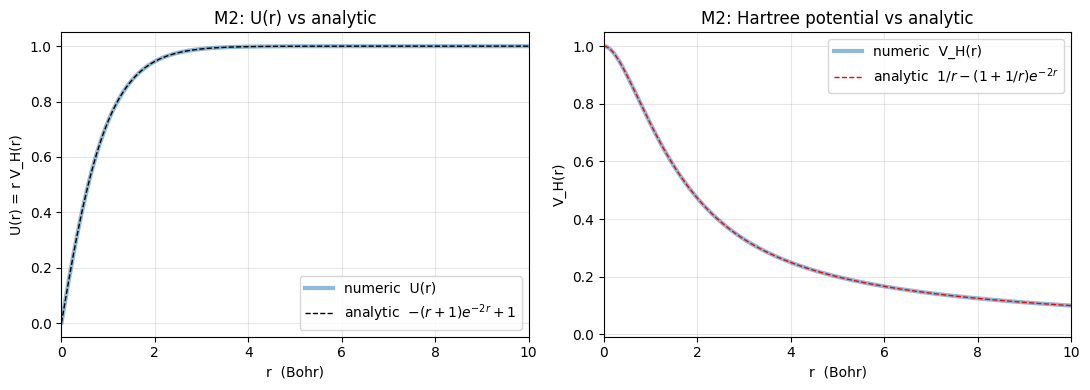

In [8]:
# Visual check: numeric U(r) and V_H(r) should lie on top of the analytic forms.
fig, (axU, axV) = plt.subplots(1, 2, figsize=(11, 4))

axU.plot(r, U, lw=3, alpha=0.5, label="numeric  U(r)")
axU.plot(r, U_exact, "k--", lw=1, label=r"analytic  $-(r+1)e^{-2r}+1$")
axU.set_xlim(0, 10)
axU.set_xlabel("r  (Bohr)")
axU.set_ylabel("U(r) = r V_H(r)")
axU.set_title("M2: U(r) vs analytic")
axU.legend()
axU.grid(alpha=0.3)

axV.plot(r, V_H, lw=3, alpha=0.5, label="numeric  V_H(r)")
axV.plot(r, VH_exact, "r--", lw=1, label=r"analytic  $1/r-(1+1/r)e^{-2r}$")
axV.set_xlim(0, 10)
axV.set_xlabel("r  (Bohr)")
axV.set_ylabel("V_H(r)")
axV.set_title("M2: Hartree potential vs analytic")
axV.legend()
axV.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Milestone 3 — Self-consistent helium, Hartree only (no exchange-correlation)

**Goal:** the first real two-electron helium energy. Both electrons sit in the
same 1s orbital; each feels the nucleus **and** the cloud of the other electron.

**The circular problem.** The potential an electron sees depends on where the
other electron is (its cloud → $V_H$), but where the electrons sit depends on the
potential. We resolve this by **self-consistency (SCF)**: guess a potential,
solve for the orbital, rebuild $V_H$ from the new orbital, and repeat until the
eigenvalue stops moving. We damp oscillation with **potential mixing**
$V_H \leftarrow (1-w)V_H^{\text{old}} + w\,V_H^{\text{new}}$, $w\approx0.3$.

**The factor-of-2 bookkeeping (the classic trap).** With two electrons the naive
Hartree term would double-count and would also let each electron repel *itself*.
In this no-XC milestone the factor 2 from spin (two electrons in one orbital)
exactly cancels the $\tfrac12$ that removes the self-interaction, so the
effective $V_H$ is just the potential of a **single normalised orbital density**
— precisely what `hartree_potential` already returns. So we use it directly:
$$ V(r) = -\frac{2}{r} + V_H(r). $$

**Total energy (PDF Eq. 13):**
$$ E = 2\varepsilon - \int V_H(r)\,u(r)^2\,dr. $$
The $2\varepsilon$ sums both electrons' single-particle energies; each already
contains the electron-electron interaction once, so summing double-counts it, and
subtracting $\int V_H u^2$ removes the extra count.

**Validation gate: $E = -2.86$ Ha.**

> **Why −2.86 and not −2.72.** This is the *restricted Hartree-Fock* value, and
> it is the **correct** M3 answer — not a bug. For a two-electron closed-shell
> singlet (both electrons in one spatial 1s orbital) the self-interaction-removed
> Hartree potential coincides *exactly* with the RHF potential, because HF
> exchange does nothing more than cancel the self-interaction: with one occupied
> orbital $(2J-K)\phi = (2J-J)\phi = J\phi$. So **SIC-Hartree $\equiv$ RHF** for
> helium. The often-quoted **−2.72** is a *later* milestone (M4: full Hartree
> **plus Slater exchange**, no correlation), confirmed by the assignment PDF
> (p. 5), which quotes −2.72 in the section where Slater exchange is already on.

In [9]:
# ----------------------------------------------------------------------------
# VALIDATION GATE 3: run the SCF loop for helium (Z = 2), Hartree only.
# scf_no_xc prints E at each iteration so convergence is visible (spec rule).
# ----------------------------------------------------------------------------
scf = scf_no_xc(Z=2.0, r=r, w=0.3, tol=1e-7, verbose=True)

print()
print("VALIDATION 3  (self-consistent helium, Hartree only, no XC)")
print(f"  converged in {scf['iterations']} iterations")
print(f"  eigenvalue eps = {scf['eps']:.6f} Ha")
print(f"  total energy E = {scf['E']:.6f} Ha     target = -2.86 Ha (= RHF)")
print(f"  |E - target|   = {abs(scf['E'] - (-2.86)):.2e} Ha")
ok_3 = abs(scf['E'] - (-2.86)) < 1e-2
print(f"  --> {'PASS' if ok_3 else 'FAIL'}")
print("  (Reaching the RHF value -2.86 is correct for a 2-electron singlet;")
print("   the -2.72 figure arrives in M4 once Slater exchange is added.)")

iter      eps (Ha)    E_total (Ha)       d eps
   1     -0.820676       -2.604019         nan
   2     -0.858483       -2.704817    3.78e-02
   3     -0.881698       -2.766210    2.32e-02
   4     -0.895894       -2.803598    1.42e-02
   5     -0.904552       -2.826358    8.66e-03
   6     -0.909822       -2.840206    5.27e-03
   7     -0.913024       -2.848625    3.20e-03
   8     -0.914966       -2.853740    1.94e-03
   9     -0.916143       -2.856844    1.18e-03
  10     -0.916855       -2.858726    7.12e-04
  11     -0.917284       -2.859865    4.29e-04
  12     -0.917543       -2.860554    2.59e-04
  13     -0.917698       -2.860969    1.55e-04
  14     -0.917791       -2.861219    9.31e-05
  15     -0.917847       -2.861370    5.56e-05
  16     -0.917880       -2.861460    3.31e-05
  17     -0.917900       -2.861513    1.96e-05
  18     -0.917911       -2.861545    1.15e-05
  19     -0.917918       -2.861564    6.74e-06
  20     -0.917922       -2.861575    3.91e-06
  21     -0.9

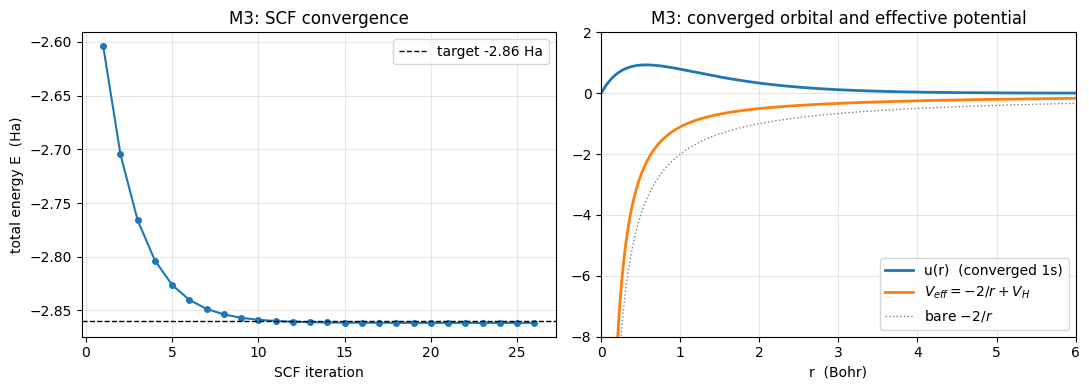

In [10]:
# Two views of the converged SCF solution.
fig, (axc, axp) = plt.subplots(1, 2, figsize=(11, 4))

# (a) Convergence: total energy vs SCF iteration, approaching -2.86.
E_hist = [E for (eps, E) in scf["history"]]
axc.plot(range(1, len(E_hist) + 1), E_hist, "o-", ms=4)
axc.axhline(-2.86, color="k", ls="--", lw=1, label="target -2.86 Ha")
axc.set_xlabel("SCF iteration")
axc.set_ylabel("total energy E  (Ha)")
axc.set_title("M3: SCF convergence")
axc.legend()
axc.grid(alpha=0.3)

# (b) The converged orbital u(r) and the effective potential it lives in.
u_he = scf["u"]
V_eff = -2.0 / r + scf["V_H"]
axp.plot(r, u_he, lw=2, label="u(r)  (converged 1s)")
axp.plot(r, V_eff, lw=2, label=r"$V_{eff}=-2/r+V_H$")
axp.plot(r, -2.0 / r, lw=1, ls=":", color="grey", label=r"bare $-2/r$")
axp.set_xlim(0, 6)
axp.set_ylim(-8, 2)
axp.set_xlabel("r  (Bohr)")
axp.set_title("M3: converged orbital and effective potential")
axp.legend()
axp.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Milestone 4 — Add LDA (Slater) exchange

**Goal:** add the first piece of the quantum correction, the **exchange**
potential, in the local density approximation (LDA).

**Two things change meaning from M3** (this is the second classic bug site, so be
deliberate):

1. **Full density.** We now use the full two-electron density
   $n(r) = u(r)^2/(2\pi r^2)$ — twice the single-orbital density of M3.
2. **Full Hartree.** Consequently the Hartree potential is the full one,
   $V_H^{\text{full}} = 2\,V_H^{\text{single}}$ — we no longer halve it for
   self-interaction, because removing the self-interaction is now the
   **exchange** term's job.

**Slater exchange (PDF Eq. 17).** LDA borrows the exchange energy of the uniform
electron gas and applies it pointwise, $V_x = -(3/\pi)^{1/3} n^{1/3}$, which in
terms of $u$ is
$$ V_x(r) = -\left(\frac{3\,u(r)^2}{2\pi^2 r^2}\right)^{1/3}. $$

The SCF potential is now $V(r) = -2/r + V_H^{\text{full}}(r) + V_x(r)$, and the
total energy (PDF Eq. 18) is
$$ E = 2\varepsilon - \int V_H^{\text{full}}\,u^2\,dr - \tfrac12\int u^2\,V_x\,dr. $$

**Validation gate: $E = -2.72$ Ha.**

> **Why LDA exchange is *less* bound than M3 (a good report point).** M3
> (SIC-Hartree) equals restricted Hartree-Fock and uses **exact exchange**, which
> cancels the self-interaction *perfectly* → $-2.86$. Slater LDA exchange is only
> an **approximate, averaged** exchange (taken from the uniform electron gas), so
> it removes the self-interaction only approximately and leaves a small residual
> self-repulsion. That extra repulsion pushes the energy *up* to $\approx -2.72$,
> i.e. less bound than the exact-exchange HF value. M5 will recover some of that
> by adding correlation ($\to -2.83$).

In [11]:
# ----------------------------------------------------------------------------
# VALIDATION GATE 4: SCF for helium with full Hartree + Slater LDA exchange.
# scf_lda_x is a SEPARATE variant from the M3 scf_no_xc (M3 is left untouched).
# It prints E each iteration so convergence is visible (spec rule).
# ----------------------------------------------------------------------------
scf_x = scf_lda_x(Z=2.0, r=r, w=0.3, tol=1e-7, verbose=True)

print()
print("VALIDATION 4  (helium, full Hartree + Slater LDA exchange, no correlation)")
print(f"  converged in {scf_x['iterations']} iterations")
print(f"  eigenvalue eps = {scf_x['eps']:.6f} Ha")
print(f"  total energy E = {scf_x['E']:.6f} Ha     target = -2.72 Ha")
print(f"  |E - target|   = {abs(scf_x['E'] - (-2.72)):.2e} Ha")
ok_4 = abs(scf_x['E'] - (-2.72)) < 1e-2
print(f"  --> {'PASS' if ok_4 else 'FAIL'}")
print(f"  (Less bound than M3's -2.86: LDA exchange removes the self-interaction")
print(f"   only approximately. M5 adds correlation to reach -2.83.)")

iter      eps (Ha)    E_total (Ha)       d eps
   1     -1.999937       -6.142418         nan
   2     -1.471668       -4.941399    5.28e-01
   3     -1.132108       -4.156488    3.40e-01
   4     -0.914296       -3.647058    2.18e-01
   5     -0.774636       -3.318582    1.40e-01
   6     -0.684952       -3.107775    8.97e-02
   7     -0.627160       -2.972724    5.78e-02
   8     -0.589726       -2.886087    3.74e-02
   9     -0.565325       -2.830283    2.44e-02
  10     -0.549307       -2.794125    1.60e-02
  11     -0.538718       -2.770532    1.06e-02
  12     -0.531670       -2.755024    7.05e-03
  13     -0.526949       -2.744755    4.72e-03
  14     -0.523768       -2.737909    3.18e-03
  15     -0.521615       -2.733316    2.15e-03
  16     -0.520150       -2.730217    1.46e-03
  17     -0.519151       -2.728116    1.00e-03
  18     -0.518466       -2.726685    6.84e-04
  19     -0.517996       -2.725708    4.70e-04
  20     -0.517673       -2.725038    3.23e-04
  21     -0.5

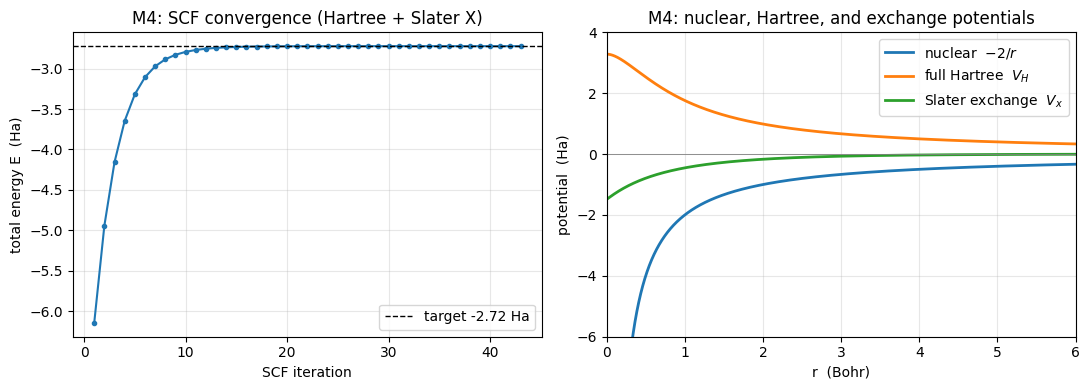

In [12]:
# Two views of the M4 solution: convergence, and the stacked potentials.
fig, (axc, axp) = plt.subplots(1, 2, figsize=(11, 4))

# (a) Convergence of the total energy toward -2.72 Ha.
Ex_hist = [E for (eps, E) in scf_x["history"]]
axc.plot(range(1, len(Ex_hist) + 1), Ex_hist, "o-", ms=3)
axc.axhline(-2.72, color="k", ls="--", lw=1, label="target -2.72 Ha")
axc.set_xlabel("SCF iteration")
axc.set_ylabel("total energy E  (Ha)")
axc.set_title("M4: SCF convergence (Hartree + Slater X)")
axc.legend()
axc.grid(alpha=0.3)

# (b) The three pieces of the effective potential. The nuclear pull is the deep
# attractive -2/r; the full Hartree is the positive (repulsive) electron-cloud
# term; the Slater exchange is the small negative (attractive) correction.
axp.plot(r, -2.0 / r, lw=2, label=r"nuclear  $-2/r$")
axp.plot(r, scf_x["V_H"], lw=2, label=r"full Hartree  $V_H$")
axp.plot(r, scf_x["V_x"], lw=2, label=r"Slater exchange  $V_x$")
axp.axhline(0, color="grey", lw=0.6)
axp.set_xlim(0, 6)
axp.set_ylim(-6, 4)
axp.set_xlabel("r  (Bohr)")
axp.set_ylabel("potential  (Ha)")
axp.set_title("M4: nuclear, Hartree, and exchange potentials")
axp.legend()
axp.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Milestone 5 — Add LDA (Perdew-Zunger) correlation: the full LDA

**Goal:** add the last piece, **correlation**, and reach the headline LDA number.

**What correlation is.** Beyond plain electrostatics (Hartree) and exchange,
electrons still avoid one another — their motion is *correlated*. LDA again
borrows the uniform electron gas, parametrising the correlation energy by the
local **Wigner-Seitz radius**
$$ r_s = \left(\frac{3}{4\pi n}\right)^{1/3}, \qquad n(r) = \frac{u^2}{2\pi r^2}\ \text{(full density)} $$
(small $r_s$ = dense, large $r_s$ = dilute). We use the **Ceperley-Alder** data
in the **Perdew-Zunger** parametrisation, which has two regimes (the boundary
$r_s = 1$ is the known pitfall — get the cutoff wrong and the energy drifts):

$$ r_s \ge 1:\quad e_c = \frac{\gamma}{1+\beta_1\sqrt{r_s}+\beta_2 r_s}, \qquad
   V_c = e_c\,\frac{1+\tfrac76\beta_1\sqrt{r_s}+\tfrac43\beta_2 r_s}{1+\beta_1\sqrt{r_s}+\beta_2 r_s} $$
$$ r_s < 1:\quad e_c = A\ln r_s + B + C\,r_s\ln r_s + D\,r_s, \qquad
   V_c = A\ln r_s + B - \tfrac{A}{3} + \tfrac23 C\,r_s\ln r_s + \tfrac{2D-C}{3}r_s $$

with $A,B,C,D = 0.0311,-0.048,0.0020,-0.0116$ and
$\gamma,\beta_1,\beta_2 = -0.1423,1.0529,0.3334$.

**Two distinct objects** (the easy thing to confuse): $e_c$ is the correlation
energy **per electron** (it goes in the total energy); $V_c = \mathrm{d}(n e_c)/\mathrm{d}n$
is the **potential** (it goes in the SCF equation). The SCF uses $V_c$, the
energy correction uses $(e_c - V_c)$.

**SCF potential:** $V(r) = -2/r + V_H^{\text{full}} + V_x + V_c$.

**Total energy** (M4 form + correlation; using
$\int f\,n\,d^3r = 2\int f\,u^2\,dr$):
$$ E = 2\varepsilon - \int V_H^{\text{full}} u^2\,dr - \tfrac12\int u^2 V_x\,dr
       + 2\int (e_c - V_c)\,u^2\,dr. $$

**Validation gate: $E = -2.83$ Ha.** Correlation is a small *attractive*
correction; it deepens M4's $-2.72$ toward the exact $-2.90$, landing at $-2.83$.

In [13]:
# ----------------------------------------------------------------------------
# VALIDATION GATE 5: full LDA SCF (Hartree + Slater exchange + PZ correlation).
# scf_lda_xc is a SEPARATE variant; M3 (scf_no_xc) and M4 (scf_lda_x) untouched.
# Prints E each iteration so convergence is visible (spec rule).
# ----------------------------------------------------------------------------
scf_xc = scf_lda_xc(Z=2.0, r=r, w=0.3, tol=1e-7, verbose=True)

print()
print("VALIDATION 5  (helium, full LDA: Hartree + Slater X + PZ correlation)")
print(f"  converged in {scf_xc['iterations']} iterations")
print(f"  eigenvalue eps = {scf_xc['eps']:.6f} Ha")
print(f"  total energy E = {scf_xc['E']:.6f} Ha     target = -2.83 Ha")
print(f"  |E - target|   = {abs(scf_xc['E'] - (-2.83)):.2e} Ha")
ok_5 = abs(scf_xc['E'] - (-2.83)) < 1e-2
print(f"  --> {'PASS' if ok_5 else 'FAIL'}")
print(f"  (Correlation deepens M4's -2.72 toward the exact -2.90, landing at -2.83.)")

iter      eps (Ha)    E_total (Ha)       d eps
   1     -1.999937       -6.127429         nan
   2     -1.491629       -4.971849    5.08e-01
   3     -1.164604       -4.216712    3.27e-01
   4     -0.954557       -3.726415    2.10e-01
   5     -0.819662       -3.409933    1.35e-01
   6     -0.732894       -3.206467    8.68e-02
   7     -0.676901       -3.075842    5.60e-02
   8     -0.640598       -2.991872    3.63e-02
   9     -0.616925       -2.937697    2.37e-02
  10     -0.601393       -2.902562    1.55e-02
  11     -0.591135       -2.879634    1.03e-02
  12     -0.584319       -2.864573    6.82e-03
  13     -0.579763       -2.854614    4.56e-03
  14     -0.576700       -2.847986    3.06e-03
  15     -0.574633       -2.843550    2.07e-03
  16     -0.573230       -2.840565    1.40e-03
  17     -0.572276       -2.838547    9.55e-04
  18     -0.571624       -2.837177    6.52e-04
  19     -0.571177       -2.836243    4.46e-04
  20     -0.570871       -2.835605    3.06e-04
  21     -0.5

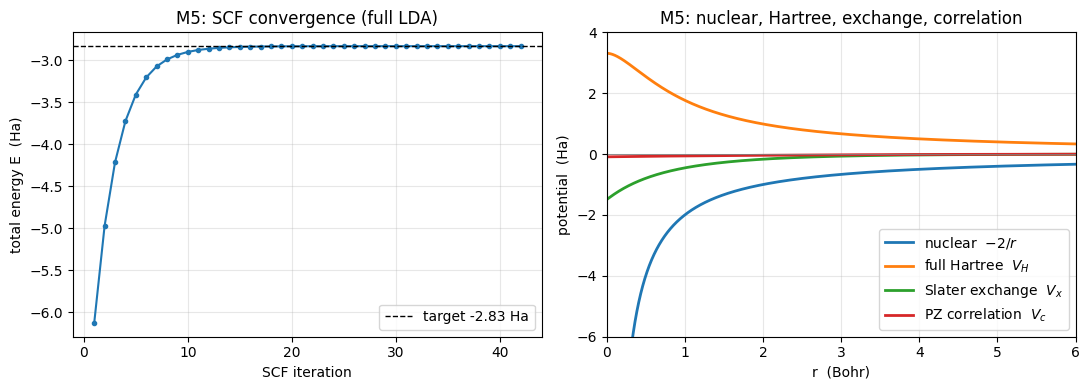

Energy ladder (Ha):
  M3  Hartree only (= RHF)          : -2.8616   (HF ref -2.86)
  M4  + Slater exchange             : -2.7236   (target -2.72)
  M5  + PZ correlation (full LDA)   : -2.8342   (target -2.83)
  exact / experiment                : -2.9037


In [14]:
# Two views of the full-LDA (M5) solution: convergence, and the four pieces of
# the effective potential, now including correlation.
fig, (axc, axp) = plt.subplots(1, 2, figsize=(11, 4))

# (a) Convergence of the total energy toward -2.83 Ha.
Exc_hist = [E for (eps, E) in scf_xc["history"]]
axc.plot(range(1, len(Exc_hist) + 1), Exc_hist, "o-", ms=3)
axc.axhline(-2.83, color="k", ls="--", lw=1, label="target -2.83 Ha")
axc.set_xlabel("SCF iteration")
axc.set_ylabel("total energy E  (Ha)")
axc.set_title("M5: SCF convergence (full LDA)")
axc.legend()
axc.grid(alpha=0.3)

# (b) The stacked potentials. Nuclear is the deep -2/r pull; full Hartree is the
# big positive (repulsive) cloud term; exchange and correlation are the small
# negative (attractive) quantum corrections -- correlation the smallest of all.
axp.plot(r, -2.0 / r, lw=2, label=r"nuclear  $-2/r$")
axp.plot(r, scf_xc["V_H"], lw=2, label=r"full Hartree  $V_H$")
axp.plot(r, scf_xc["V_x"], lw=2, label=r"Slater exchange  $V_x$")
axp.plot(r, scf_xc["V_c"], lw=2, label=r"PZ correlation  $V_c$")
axp.axhline(0, color="grey", lw=0.6)
axp.set_xlim(0, 6)
axp.set_ylim(-6, 4)
axp.set_xlabel("r  (Bohr)")
axp.set_ylabel("potential  (Ha)")
axp.set_title("M5: nuclear, Hartree, exchange, correlation")
axp.legend()
axp.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# The march toward the truth, all in one place (a preview of the M6 table).
print("Energy ladder (Ha):")
print(f"  M3  Hartree only (= RHF)          : {scf['E']:.4f}   (HF ref -2.86)")
print(f"  M4  + Slater exchange             : {scf_x['E']:.4f}   (target -2.72)")
print(f"  M5  + PZ correlation (full LDA)   : {scf_xc['E']:.4f}   (target -2.83)")
print(f"  exact / experiment                : -2.9037")

---
## Milestone 6 — Report figures and the results table

**No new physics here.** We reuse the already-converged SCF outputs from M3, M4,
and M5 (`scf`, `scf_x`, `scf_xc` computed above) and turn them into clean,
publication-quality figures and a results table for the written report.

We save four figures (each as **PNG and PDF**) plus the results table (as a
**LaTeX** snippet and a **CSV**) into a git-tracked `figures/` folder:

1. **SCF convergence** — total energy vs iteration, M3/M4/M5 overlaid.
2. **The converged orbital** — $u(r)$ and the radial density for the full-LDA (M5)
   solution.
3. **Stacked potentials** — nuclear, full Hartree, exchange, correlation, and the
   total effective potential, for the M5 solution.
4. **Energy comparison** — the computed energies against the Hartree-Fock and
   exact references.

In [15]:
# Setup: a git-tracked figures/ folder, publication-quality plot defaults, and a
# small helper that saves every figure as BOTH PNG (raster, for quick viewing)
# and PDF (vector, for LaTeX). All physics is already done; this only formats it.
import os

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,      # on-screen
    "savefig.dpi": 200,     # raster PNG resolution
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "lines.linewidth": 2.0,
    "savefig.bbox": "tight",
})

def save_fig(fig, name):
    """Save a figure to figures/<name>.png and figures/<name>.pdf."""
    paths = []
    for ext in ("png", "pdf"):
        p = os.path.join(FIG_DIR, f"{name}.{ext}")
        fig.savefig(p)
        paths.append(p)
    print("saved:", ", ".join(paths))

# Reference values for the report (atomic units, Hartree).
E_HF_REF = -2.8617     # restricted Hartree-Fock for helium
E_EXACT = -2.9037      # essentially exact / experimental
print(f"Reusing converged energies:  M3 = {scf['E']:.4f},  "
      f"M4 = {scf_x['E']:.4f},  M5 = {scf_xc['E']:.4f}  (Ha)")

Reusing converged energies:  M3 = -2.8616,  M4 = -2.7236,  M5 = -2.8342  (Ha)


saved: figures/fig1_scf_convergence.png, figures/fig1_scf_convergence.pdf


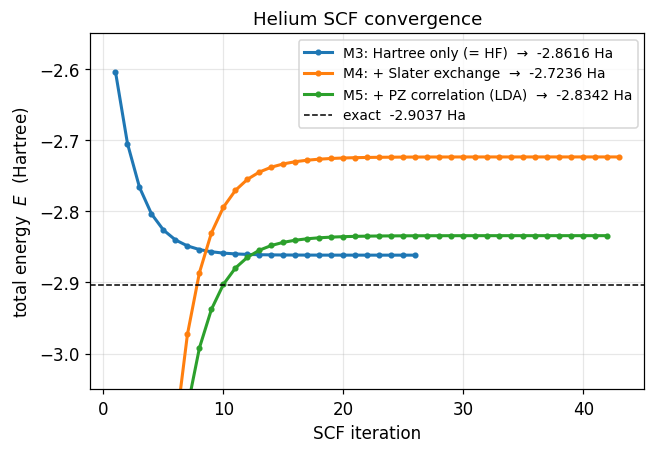

In [16]:
# FIGURE 1 — SCF convergence: total energy vs iteration, M3/M4/M5 overlaid.
# Each history is a list of (eps, E) per iteration; we plot the energy E.
fig1, ax = plt.subplots(figsize=(6.5, 4.2))
for res, label, color in [(scf,   "M3: Hartree only (= HF)",      "C0"),
                          (scf_x, "M4: + Slater exchange",        "C1"),
                          (scf_xc,"M5: + PZ correlation (LDA)",   "C2")]:
    E_iter = [E for (eps, E) in res["history"]]
    ax.plot(range(1, len(E_iter) + 1), E_iter, "o-", ms=3, color=color,
            label=f"{label}  →  {res['E']:.4f} Ha")
ax.axhline(E_EXACT, color="k", ls="--", lw=1, label=f"exact  {E_EXACT:.4f} Ha")
ax.set_xlabel("SCF iteration")
ax.set_ylabel("total energy  $E$  (Hartree)")
ax.set_title("Helium SCF convergence")
ax.set_ylim(-3.05, -2.55)
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
save_fig(fig1, "fig1_scf_convergence")
plt.show()

saved: figures/fig2_orbital_density.png, figures/fig2_orbital_density.pdf


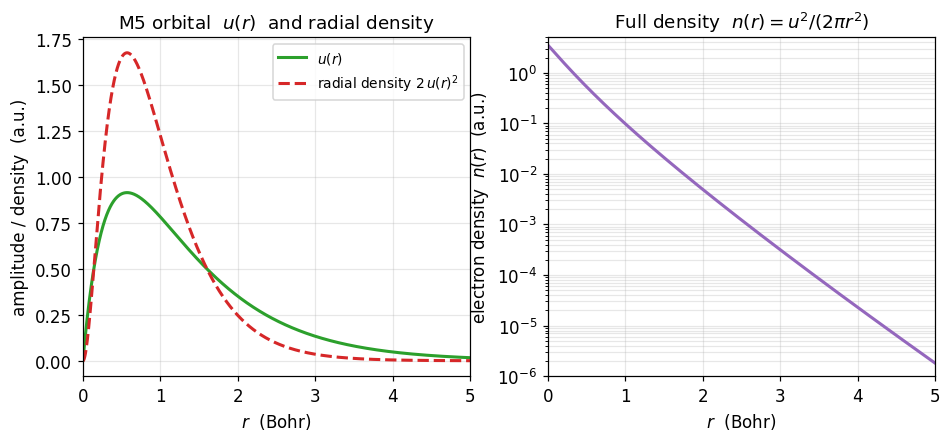

In [17]:
# FIGURE 2 — the converged full-LDA (M5) orbital and the electron density.
# Left:  u(r), the radial wavefunction (u = r R), and the radial probability
#        density 2 u^2 (the chance of finding an electron between r and r+dr,
#        times the 2 electrons; integrates to 2).
# Right: n(r) = u^2 / (2 pi r^2), the full 3-D electron number density, which is
#        what the LDA functionals actually see.
u5 = scf_xc["u"]
n5 = u5**2 / (2.0 * np.pi * r**2)

fig2, (axL, axR) = plt.subplots(1, 2, figsize=(10, 4.0))

axL.plot(r, u5, color="C2", label=r"$u(r)$")
axL.plot(r, 2.0 * u5**2, color="C3", ls="--", label=r"radial density $2\,u(r)^2$")
axL.set_xlim(0, 5)
axL.set_xlabel(r"$r$  (Bohr)")
axL.set_ylabel("amplitude / density  (a.u.)")
axL.set_title("M5 orbital  $u(r)$  and radial density")
axL.legend()
axL.grid(alpha=0.3)

axR.semilogy(r, n5, color="C4")
axR.set_xlim(0, 5)
axR.set_ylim(1e-6, 5)
axR.set_xlabel(r"$r$  (Bohr)")
axR.set_ylabel(r"electron density  $n(r)$  (a.u.)")
axR.set_title(r"Full density  $n(r)=u^2/(2\pi r^2)$")
axR.grid(alpha=0.3, which="both")

save_fig(fig2, "fig2_orbital_density")
plt.show()

saved: figures/fig3_potentials.png, figures/fig3_potentials.pdf


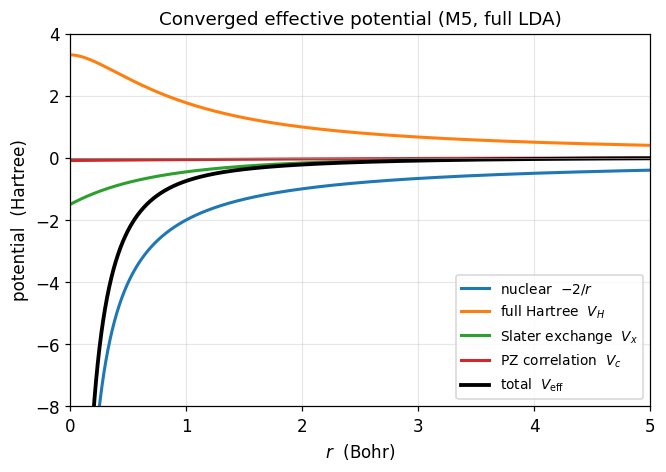

In [18]:
# FIGURE 3 — the pieces of the converged M5 effective potential on one axis:
# nuclear (-2/r), full Hartree, Slater exchange, PZ correlation, and their sum
# V_eff. The nuclear pull is the deep attractive well; the full Hartree is the
# big positive (repulsive) electron-cloud term; exchange and correlation are the
# small negative (attractive) quantum corrections (correlation the smallest).
V_nuc = -2.0 / r
V_eff = V_nuc + scf_xc["V_H"] + scf_xc["V_x"] + scf_xc["V_c"]

fig3, ax = plt.subplots(figsize=(6.8, 4.4))
ax.plot(r, V_nuc,         color="C0", label=r"nuclear  $-2/r$")
ax.plot(r, scf_xc["V_H"], color="C1", label=r"full Hartree  $V_H$")
ax.plot(r, scf_xc["V_x"], color="C2", label=r"Slater exchange  $V_x$")
ax.plot(r, scf_xc["V_c"], color="C3", label=r"PZ correlation  $V_c$")
ax.plot(r, V_eff, color="k", lw=2.5, label=r"total  $V_{\mathrm{eff}}$")
ax.axhline(0, color="grey", lw=0.6)
ax.set_xlim(0, 5)
ax.set_ylim(-8, 4)
ax.set_xlabel(r"$r$  (Bohr)")
ax.set_ylabel("potential  (Hartree)")
ax.set_title("Converged effective potential (M5, full LDA)")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
save_fig(fig3, "fig3_potentials")
plt.show()

saved: figures/fig4_energy_comparison.png, figures/fig4_energy_comparison.pdf


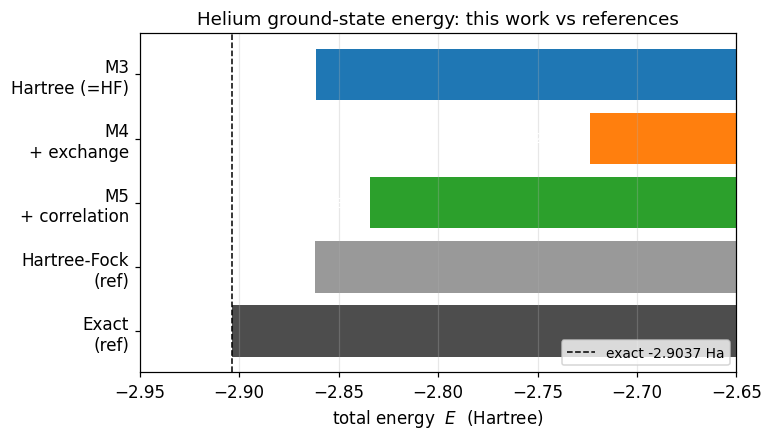

In [19]:
# FIGURE 4 — energy comparison: this work (M3/M4/M5) vs the HF and exact
# references, as a horizontal bar chart with the exact value marked.
labels = ["M3\nHartree (=HF)", "M4\n+ exchange",
          "M5\n+ correlation", "Hartree-Fock\n(ref)", "Exact\n(ref)"]
values = [scf["E"], scf_x["E"], scf_xc["E"], E_HF_REF, E_EXACT]
colors = ["C0", "C1", "C2", "0.6", "0.3"]

fig4, ax = plt.subplots(figsize=(7.0, 4.0))
bars = ax.barh(labels, values, color=colors)
ax.axvline(E_EXACT, color="k", ls="--", lw=1, label=f"exact {E_EXACT:.4f} Ha")
ax.set_xlim(-2.95, -2.65)
ax.set_xlabel("total energy  $E$  (Hartree)")
ax.set_title("Helium ground-state energy: this work vs references")
ax.invert_yaxis()                 # first row on top
for bar, v in zip(bars, values):  # annotate each bar with its value
    ax.text(v - 0.004, bar.get_y() + bar.get_height() / 2,
            f"{v:.4f}", va="center", ha="right", color="white", fontsize=9)
ax.legend(loc="lower right")
ax.grid(alpha=0.3, axis="x")
save_fig(fig4, "fig4_energy_comparison")
plt.show()

In [20]:
# RESULTS TABLE — printed here, and written to figures/ as LaTeX and CSV so the
# report can include it directly. "This work" uses the actual converged numbers;
# "Reference" is the milestone target (and the HF / exact literature values).
# rows: (method, this_work_or_None, reference_value)
table_rows = [
    ("M3: SIC-Hartree, no XC (= RHF)", scf["E"],    -2.86),
    ("M4: + Slater LDA exchange",      scf_x["E"],  -2.72),
    ("M5: + PZ correlation (full LDA)",scf_xc["E"], -2.83),
    ("Hartree-Fock (reference)",       None,        E_HF_REF),
    ("Exact / experiment",             None,        E_EXACT),
]

# --- printed table ---
print(f"{'Method':35s} {'This work (Ha)':>15s} {'Reference (Ha)':>15s}")
print("-" * 67)
for name, mine, ref in table_rows:
    mine_s = f"{mine:.4f}" if mine is not None else "--"
    print(f"{name:35s} {mine_s:>15s} {ref:>15.4f}")

# --- CSV ---
csv_path = os.path.join(FIG_DIR, "results_table.csv")
with open(csv_path, "w") as f:
    f.write("method,this_work_Ha,reference_Ha\n")
    for name, mine, ref in table_rows:
        mine_s = f"{mine:.4f}" if mine is not None else ""
        f.write(f"\"{name}\",{mine_s},{ref:.4f}\n")

# --- LaTeX snippet (a standalone table environment) ---
tex_path = os.path.join(FIG_DIR, "results_table.tex")
lines = [
    r"\begin{table}[t]",
    r"  \centering",
    r"  \caption{Helium ground-state energy from this DFT program, by milestone,"
    r" compared with Hartree-Fock and the exact value (Hartree).}",
    r"  \label{tab:helium_energies}",
    r"  \begin{tabular}{lrr}",
    r"    \hline",
    r"    Method & This work (Ha) & Reference (Ha) \\",
    r"    \hline",
]
for name, mine, ref in table_rows:
    mine_s = f"${mine:.4f}$" if mine is not None else "--"
    safe = name.replace("=", r"$=$")
    lines.append(f"    {safe} & {mine_s} & ${ref:.4f}$ \\\\")
lines += [r"    \hline", r"  \end{tabular}", r"\end{table}", ""]
with open(tex_path, "w") as f:
    f.write("\n".join(lines))

print()
print("wrote:", csv_path, "and", tex_path)

Method                               This work (Ha)  Reference (Ha)
-------------------------------------------------------------------
M3: SIC-Hartree, no XC (= RHF)              -2.8616         -2.8600
M4: + Slater LDA exchange                   -2.7236         -2.7200
M5: + PZ correlation (full LDA)             -2.8342         -2.8300
Hartree-Fock (reference)                         --         -2.8617
Exact / experiment                               --         -2.9037

wrote: figures/results_table.csv and figures/results_table.tex


In [21]:
# VALIDATION GATE 6: confirm every expected artifact exists on disk, and that
# the table numbers match the validated milestones (within the 1e-2 gates).
expected = [
    "fig1_scf_convergence.png", "fig1_scf_convergence.pdf",
    "fig2_orbital_density.png", "fig2_orbital_density.pdf",
    "fig3_potentials.png",      "fig3_potentials.pdf",
    "fig4_energy_comparison.png","fig4_energy_comparison.pdf",
    "results_table.csv",        "results_table.tex",
]
print("VALIDATION 6  (figures and table written to figures/)")
all_present = True
for fname in expected:
    p = os.path.join(FIG_DIR, fname)
    ok = os.path.exists(p) and os.path.getsize(p) > 0
    all_present &= ok
    print(f"  [{'OK' if ok else 'MISSING'}] {p}  ({os.path.getsize(p)} bytes)")

# Numbers still match the validated milestones?
checks = [abs(scf['E']   - (-2.86)) < 1e-2,
          abs(scf_x['E']  - (-2.72)) < 1e-2,
          abs(scf_xc['E'] - (-2.83)) < 1e-2]
print(f"  table energies match milestone gates: {'YES' if all(checks) else 'NO'}")
print(f"  --> {'PASS' if (all_present and all(checks)) else 'FAIL'}")

VALIDATION 6  (figures and table written to figures/)
  [OK] figures/fig1_scf_convergence.png  (81484 bytes)
  [OK] figures/fig1_scf_convergence.pdf  (22085 bytes)
  [OK] figures/fig2_orbital_density.png  (125235 bytes)
  [OK] figures/fig2_orbital_density.pdf  (21074 bytes)
  [OK] figures/fig3_potentials.png  (77070 bytes)
  [OK] figures/fig3_potentials.pdf  (21071 bytes)
  [OK] figures/fig4_energy_comparison.png  (55650 bytes)
  [OK] figures/fig4_energy_comparison.pdf  (18372 bytes)
  [OK] figures/results_table.csv  (242 bytes)
  [OK] figures/results_table.tex  (602 bytes)
  table energies match milestone gates: YES
  --> PASS
